# Notebook 4: Model and Tool Analysis

**Goal:** Compare models and tools without hiding uncertainty or repository imbalance.

**Inputs:** `evaluation_attempts.csv`, `evaluation_candidates.csv`, `evaluation_repositories.csv`

**RQs addressed:** RQ5

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from analysis.statistics import bootstrap_ci, repository_blocked_bootstrap
from analysis.plots import (
    metric_delta_distribution,
    cost_vs_improvement_scatter,
    robustness_heatmap,
)

sns.set_theme(style='whitegrid')

DATA_DIR   = Path('../data')
REQUIRED_FILES = ['evaluation_attempts.csv', 'evaluation_candidates.csv']
missing = [name for name in REQUIRED_FILES if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f'Missing required analysis CSVs in {DATA_DIR}: {missing}')
attempts   = pd.read_csv(DATA_DIR / 'evaluation_attempts.csv')
candidates = pd.read_csv(DATA_DIR / 'evaluation_candidates.csv')
repos      = pd.read_csv(DATA_DIR / 'evaluation_repositories.csv') if (DATA_DIR / 'evaluation_repositories.csv').exists() else pd.DataFrame()

## 1. Model / Tool Participation and Data Completeness

Lists which models and tools ran, how many attempts each produced, and whether any configuration (model, tool, repository) has disproportionately few observations. Imbalanced participation limits what can be concluded from later comparisons.


In [2]:
# LLM models
llm = attempts[attempts.get('lane', pd.Series()) == 'llm']
if 'model' in llm.columns:
    print('LLM models:')
    print(llm.groupby('model').size().sort_values(ascending=False))

# Agentic tools
agentic = attempts[attempts.get('lane', pd.Series()) == 'agentic']
if 'tool_id' in agentic.columns:
    print('\nAgentic tools:')
    print(agentic.groupby('tool_id').size().sort_values(ascending=False))

LLM models:
model
gpt-oss-120b    3
dtype: int64

Agentic tools:
tool_id
codex     1
gemini    1
dtype: int64


## 2. Outcome Rates with Confidence Intervals

Success rate per model/tool with 95% bootstrap CIs (percentile, 9999 resamples), plus pairwise Mann-Whitney U with **Bonferroni correction** across all group pairs. VEP rate is reported alongside `validated_success`.

,group,n,mean,ci_lower,ci_upper,vep_rate,vep_lower,vep_upper
0,gpt-oss-120b,3,0.666667,0.0,1.0,0.666667,0.0,1.0


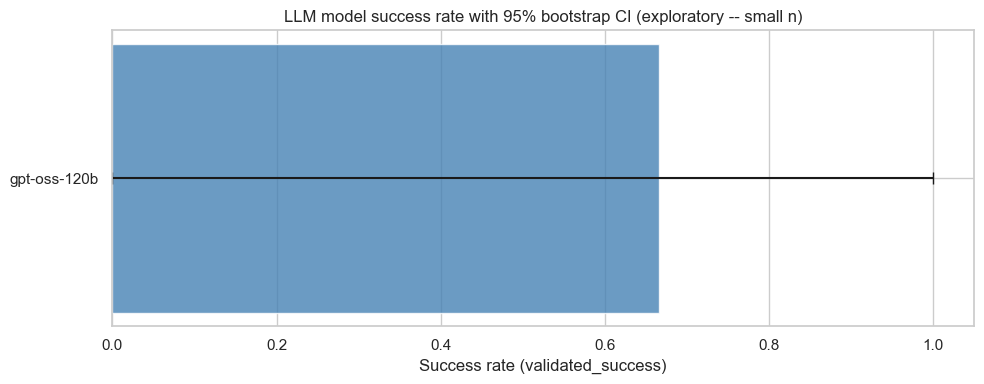

Only 1 group(s) -- no pairwise comparison possible.


In [3]:
from analysis.statistics import bootstrap_ci, bonferroni_correct, mann_whitney_u

def ci_for_group(df, group_col, metric_col='validated_success'):
    rows = []
    for grp, sub in df.groupby(group_col):
        vals = sub[metric_col].dropna().astype(float)
        if len(vals) < 2:
            rows.append({'group': grp, 'n': len(vals),
                         'mean': float(vals.mean()) if len(vals) else float('nan'),
                         'ci_lower': float('nan'), 'ci_upper': float('nan')})
            continue
        ci = bootstrap_ci(vals, stat_fn=np.mean)
        rows.append({'group': grp, 'n': len(vals), 'mean': ci.estimate,
                     'ci_lower': ci.lower, 'ci_upper': ci.upper})
    return pd.DataFrame(rows).sort_values('mean', ascending=False)


def pairwise_bonferroni(df, group_col, metric_col='validated_success', alpha=0.05):
    """Pairwise Mann-Whitney U with Bonferroni correction across all group pairs."""
    groups = sorted(df[group_col].dropna().unique())
    if len(groups) < 2:
        print(f'Only {len(groups)} group(s) -- no pairwise comparison possible.')
        return
    pairs = [(a, b) for i, a in enumerate(groups) for b in groups[i+1:]]
    p_values, labels, effects = [], [], []
    for a, b in pairs:
        x = df[df[group_col] == a][metric_col].dropna().astype(float)
        y = df[df[group_col] == b][metric_col].dropna().astype(float)
        res = mann_whitney_u(x, y)
        p_values.append(res.p_value)
        labels.append(f'{a} vs {b}')
        effects.append(round(res.effect_size, 3))
    corr = bonferroni_correct(p_values, alpha=alpha)
    col_sig = f"sig (Bonferroni alpha={corr['alpha_corrected']:.4f})"
    pw = pd.DataFrame({
        'comparison': labels,
        'p_value': [round(p, 4) for p in p_values],
        "Cliff's delta": effects,
        col_sig: corr['reject'],
    })
    print(f"Bonferroni: alpha={alpha} / k={corr['k']} -> threshold={corr['alpha_corrected']:.4f}")
    display(pw)


if 'model' in llm.columns and 'validated_success' in llm.columns:
    model_ci = ci_for_group(llm, 'model')
    if 'validated_evidence_positive' in llm.columns:
        vep_ci = ci_for_group(llm, 'model', 'validated_evidence_positive').rename(
            columns={'mean': 'vep_rate', 'ci_lower': 'vep_lower', 'ci_upper': 'vep_upper', 'n': 'n_vep'})
        model_ci = model_ci.merge(vep_ci[['group', 'vep_rate', 'vep_lower', 'vep_upper']], on='group', how='left')
    display(model_ci)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(model_ci['group'], model_ci['mean'],
            xerr=[model_ci['mean'] - model_ci['ci_lower'],
                  model_ci['ci_upper'] - model_ci['mean']],
            capsize=4, color='steelblue', alpha=0.8)
    ax.set_xlabel('Success rate (validated_success)')
    ax.set_title('LLM model success rate with 95% bootstrap CI (exploratory -- small n)')
    plt.tight_layout()
    plt.show()

    pairwise_bonferroni(llm, 'model')


,group,n,mean,ci_lower,ci_upper
0,codex,1,1.0,NaN,NaN
1,gemini,1,0.0,NaN,NaN


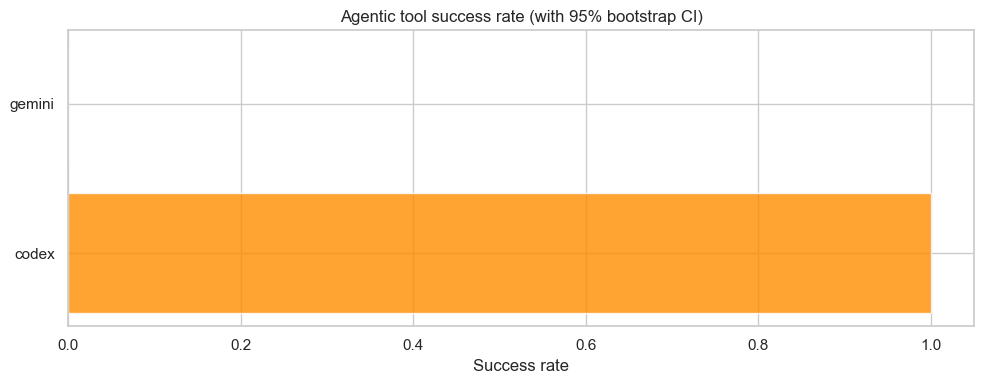

Bonferroni: alpha=0.05 / k=1 -> threshold=0.0500


,comparison,p_value,Cliff's delta,sig (Bonferroni alpha=0.0500)
0,codex vs gemini,1.0,1.0,False


In [4]:
if 'tool_id' in agentic.columns and 'validated_success' in agentic.columns:
    tool_ci = ci_for_group(agentic, 'tool_id')
    display(tool_ci)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(tool_ci['group'], tool_ci['mean'],
            xerr=[tool_ci['mean'] - tool_ci['ci_lower'],
                  tool_ci['ci_upper'] - tool_ci['mean']],
            capsize=4, color='darkorange', alpha=0.8)
    ax.set_xlabel('Success rate')
    ax.set_title('Agentic tool success rate (with 95% bootstrap CI)')
    plt.tight_layout()
    plt.show()

    pairwise_bonferroni(agentic, 'tool_id')


## 3. Metric Improvements

Distribution of coverage and mutation score deltas per model/tool, plotted as boxplots. Only attempts with non-missing deltas are shown -- failed attempts that produced no measurement are excluded, so the distributions are conditional on output being generated. Interpret alongside Section 2 success rates.


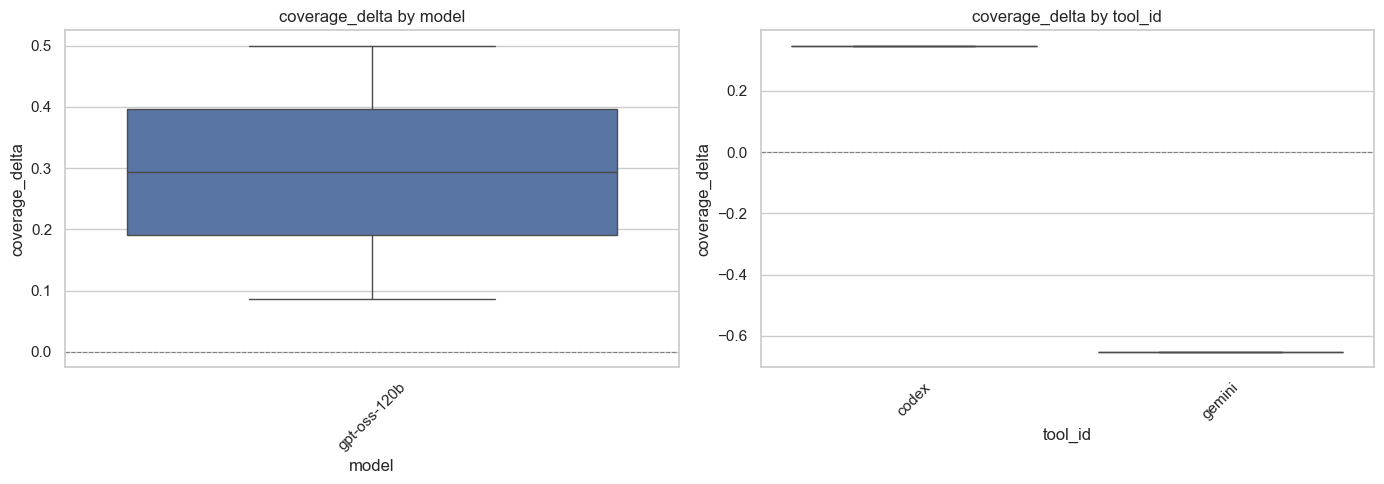

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'model' in llm.columns and 'coverage_delta' in llm.columns:
    metric_delta_distribution(llm, 'coverage_delta', 'model', ax=axes[0])
if 'tool_id' in agentic.columns and 'coverage_delta' in agentic.columns:
    metric_delta_distribution(agentic, 'coverage_delta', 'tool_id', ax=axes[1])
plt.tight_layout()
plt.show()

## 4. Cost Efficiency

Validated successes per 1k `effective_tokens` per model/tool, computed at the candidate level (LLM cumulative chain vs agentic total run) so a model's repair-chain cost is counted in full.

In [6]:
# Candidate-level, lane-fair: successes per 1k effective tokens per model/tool.
llm_c = candidates[candidates['lane'] == 'llm'] if 'lane' in candidates.columns else candidates.iloc[0:0]
agentic_c = candidates[candidates['lane'] == 'agentic'] if 'lane' in candidates.columns else candidates.iloc[0:0]
for label, df, group_col in [('LLM models', llm_c, 'model'), ('Agentic tools', agentic_c, 'tool_id')]:
    if (group_col in df.columns and 'effective_tokens' in df.columns
            and 'any_validated_success' in df.columns and len(df)):
        eff = df.groupby(group_col).apply(
            lambda g: g['any_validated_success'].sum() / (g['effective_tokens'].sum() / 1000)
            if g['effective_tokens'].sum() > 0 else float('nan')
        )
        print(f'{label} -- validated successes per 1k effective tokens (candidate-level):')
        print(eff.sort_values(ascending=False))
        print()

LLM models -- validated successes per 1k effective tokens (candidate-level):
model
gpt-oss-120b    0.184843
dtype: float64



Agentic tools -- validated successes per 1k effective tokens (candidate-level):
tool_id
codex    0.002282
dtype: float64



## 5. Robustness Across Repositories

Heatmap of success rate per model/tool x repository. With only 2 repositories, this diagnoses whether any apparent advantage is driven by a single codebase rather than generalising. A model that dominates on one repository but fails on the other is not robust.


C:\Users\milit\AppData\Local\Temp\ipykernel_51196\2665552197.py:10: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


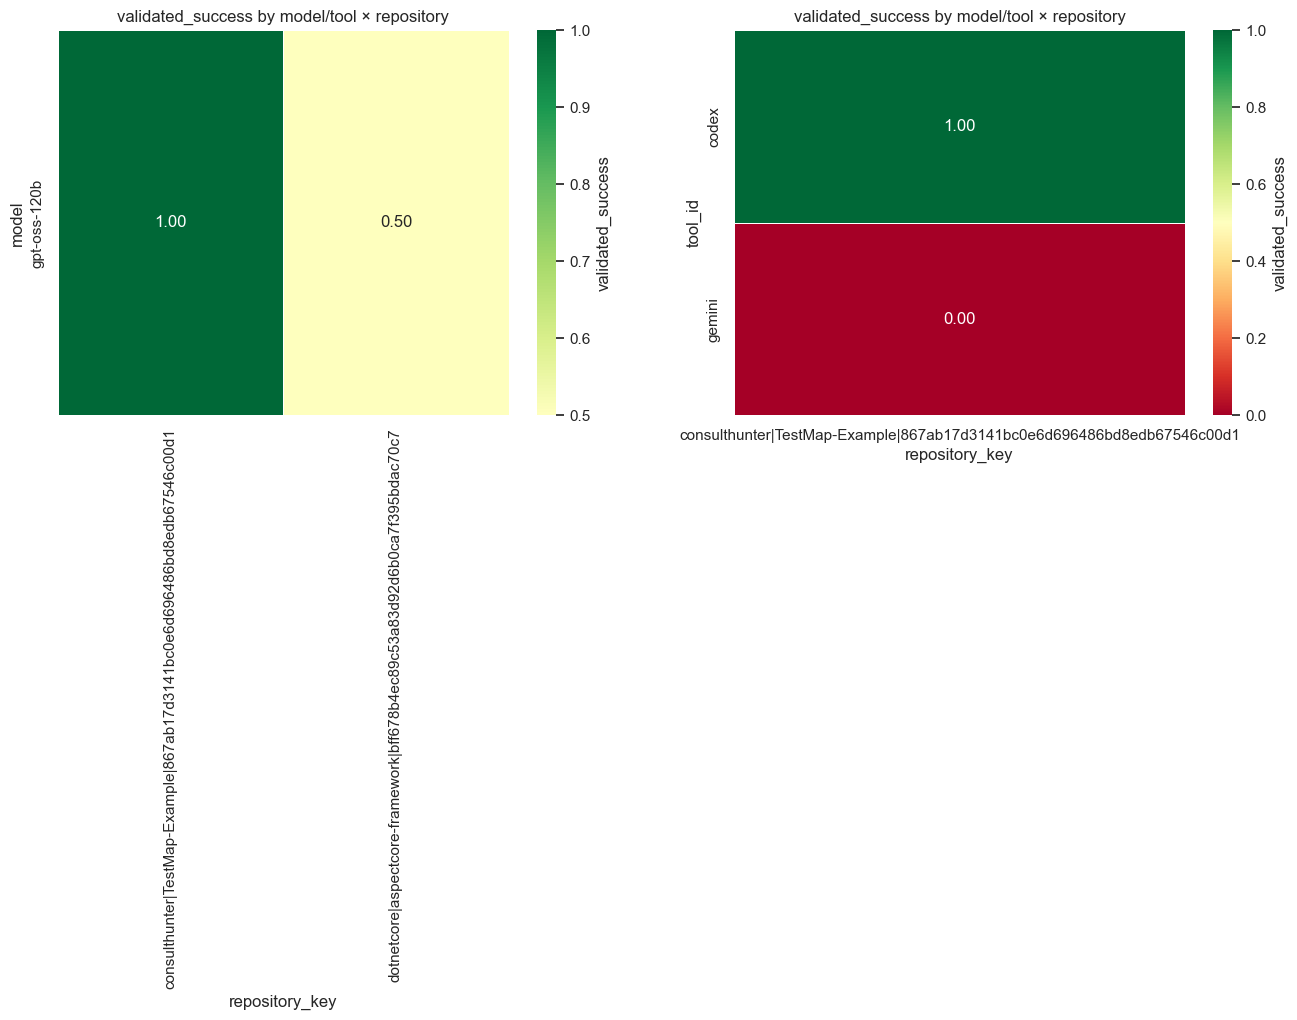

In [7]:
# Robustness heatmap: model/tool × repository
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if 'model' in llm.columns and 'repository_key' in llm.columns and 'validated_success' in llm.columns:
    robustness_heatmap(llm, 'model', 'repository_key', 'validated_success', ax=axes[0])

if 'tool_id' in agentic.columns and 'repository_key' in agentic.columns and 'validated_success' in agentic.columns:
    robustness_heatmap(agentic, 'tool_id', 'repository_key', 'validated_success', ax=axes[1])

plt.tight_layout()
plt.show()

## 6. Best-by-Category Summary

Ranks models and tools by point-estimate mean per metric category (best overall / coverage / mutation).

In [8]:
# Best-by-category (candidate-level). Point estimates only; unstable at small N.
prod = candidates.copy()
prod['producer'] = prod.apply(lambda r: r['model'] if r['lane'] == 'llm' else r.get('tool_id', r['model']), axis=1)
summ_rows = []
for (lane, producer), g in prod.groupby(['lane', 'producer']):
    succ = g['any_validated_success'].mean() if 'any_validated_success' in g else float('nan')
    vep = ((g['validated_evidence_positive_count'] > 0).mean()
           if 'validated_evidence_positive_count' in g else float('nan'))
    tok = g['effective_tokens'].median() if 'effective_tokens' in g else float('nan')
    spk = (g['any_validated_success'].sum() / (g['effective_tokens'].sum() / 1000)
           if 'effective_tokens' in g and g['effective_tokens'].sum() > 0 else float('nan'))
    nrepo = g['repository_key'].nunique() if 'repository_key' in g else 0
    robust = (g.groupby('repository_key')['any_validated_success'].mean().min()
              if 'repository_key' in g and nrepo > 0 else float('nan'))
    summ_rows.append({'lane': lane, 'producer': producer, 'n': len(g), 'success_rate': succ,
                      'vep_rate': vep, 'median_tokens': tok, 'successes_per_1k_tok': spk,
                      'repos': nrepo, 'min_repo_success': robust})
summ = pd.DataFrame(summ_rows)
display(summ.round(3))

def winner(col, ascending=False):
    s = summ.dropna(subset=[col])
    if s.empty:
        return 'n/a'
    r = s.sort_values(col, ascending=ascending).iloc[0]
    return f"{r['producer']} ({r['lane']}, {col}={r[col]:.3f})"

print('Best overall (success rate):      ', winner('success_rate'))
print('Best practical impact (VEP rate): ', winner('vep_rate'))
print('Most cost-effective (succ/1k tok):', winner('successes_per_1k_tok'))
print('Most robust (min per-repo success):', winner('min_repo_success'))
print('\nHypothesis-generation only: rankings are unstable and would reverse with a few more attempts.')

,lane,producer,n,success_rate,vep_rate,median_tokens,successes_per_1k_tok,repos,min_repo_success
0,agentic,codex,1,1.0,1.0,438145.0,0.002,1,1.0
1,llm,gpt-oss-120b,2,1.0,1.0,5410.0,0.185,2,1.0


Best overall (success rate):       codex (agentic, success_rate=1.000)
Best practical impact (VEP rate):  codex (agentic, vep_rate=1.000)
Most cost-effective (succ/1k tok): gpt-oss-120b (llm, successes_per_1k_tok=0.185)
Most robust (min per-repo success): codex (agentic, min_repo_success=1.000)

Hypothesis-generation only: rankings are unstable and would reverse with a few more attempts.


## 7. Outcome Classification by Model/Tool

Full outcome breakdown per model/tool as a stacked bar, showing the proportion reaching each stage (ValidatedEvidencePositive, ValidatedLowImpact, FailedEvidencePositive, BuildFailed, etc.). This is more diagnostic than the binary success rate because it reveals where each model/tool tends to fail.


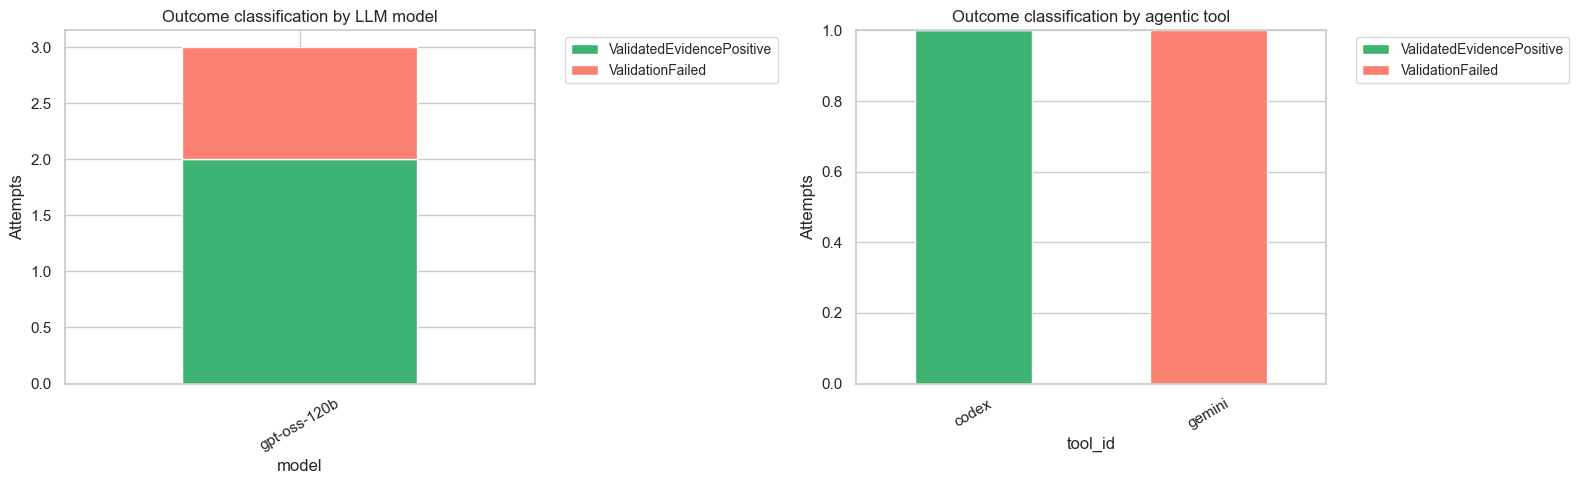

In [9]:
from analysis.plots import outcome_classification_bar

if 'outcome_classification' in attempts.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    if 'model' in llm.columns:
        outcome_classification_bar(llm, group_col='model', ax=axes[0])
        axes[0].set_title('Outcome classification by LLM model')
    if 'tool_id' in agentic.columns:
        outcome_classification_bar(agentic, group_col='tool_id', ax=axes[1])
        axes[1].set_title('Outcome classification by agentic tool')
    plt.tight_layout()
    plt.show()
else:
    print('outcome_classification column not found.')

## 8. Success Predictors (RQ7)

Structural source-method metrics (CC, SLOC, ELOC, coupling, DIT, MI) are one collinear family,
collapsed into a single `complexity_index` (z-scored, sign-aligned -- MI inverted; equal-weight
at small N, PCA PC1 when N supports). Distinct axes kept separate: `access_strategy`,
`source_member_visibility`, `source_method_baseline_coverage`, and mapping `test_mapping_count`
(trace-count proxy).

Reported as **univariate screening** (each predictor vs the binary `any_validated_success`), with a
**collinearity matrix** so no single metric is over-read, plus a variance audit. Screening the
binary outcome (not `coverage_delta`) avoids the baseline-coverage ceiling confound. The
joint/regularized model is deferred to large N (see analysis_plan.md, PCA protocol).

In [10]:
import numpy as np

# Structural family (sign: +1 increases with complexity; MI is inverse).
STRUCT = [('source_method_cc', 1), ('source_method_sloc', 1), ('source_method_eloc', 1),
          ('source_method_coupling', 1), ('source_method_dit', 1), ('source_method_mi', -1)]
struct_cols = [(c, s) for c, s in STRUCT if c in candidates.columns]

# One row per distinct source method (metrics are method properties, constant across lanes).
methods = candidates.drop_duplicates('candidate_key').set_index('candidate_key')

# z-score + sign-align -> equal-weight complexity_index (robust at small N).
z = pd.DataFrame(index=methods.index)
for c, sign in struct_cols:
    v = pd.to_numeric(methods[c], errors='coerce')
    sd = v.std(ddof=0)
    z[c] = sign * ((v - v.mean()) / sd) if sd and sd > 0 else 0.0
methods['complexity_index'] = z.mean(axis=1)

n_methods = len(methods)
PCA_MIN = 20
print(f'Distinct source methods (pooled): {n_methods}')
if n_methods >= PCA_MIN and len(struct_cols) >= 2:
    # Dependency-free PCA via SVD on the standardized matrix.
    M = z.to_numpy(dtype=float)
    M = M - M.mean(axis=0)
    _, S, Vt = np.linalg.svd(M, full_matrices=False)
    pc1 = M @ Vt[0]
    if Vt[0][0] < 0:  # sign-align so higher index = more complex
        pc1 = -pc1
    methods['complexity_index'] = pc1
    ev = (S ** 2) / (S ** 2).sum()
    print(f'PCA active: PC1 explains {ev[0] * 100:.1f}% of variance')
else:
    print(f'PCA deferred (N={n_methods} < {PCA_MIN}); using equal-weight z-average complexity_index.')

# Collinearity matrix: structural family + distinct numeric axes.
distinct_numeric = [c for c in ['source_method_baseline_coverage', 'test_mapping_count']
                    if c in methods.columns]
collin_cols = [c for c, _ in struct_cols] + distinct_numeric
if len(collin_cols) >= 2:
    collin = methods[collin_cols].apply(pd.to_numeric, errors='coerce').corr()
    print('\nPredictor collinearity matrix (structural family co-moves):')
    display(collin.round(2))

# Merge complexity_index back to (candidate, lane) rows for outcome screening.
scr = candidates.merge(methods[['complexity_index']], left_on='candidate_key',
                       right_index=True, how='left')

# Univariate screen of numeric predictors vs the BINARY outcome (any_validated_success).
print('\nUnivariate predictor screen vs any_validated_success:')
num_preds = ['complexity_index', 'source_method_baseline_coverage', 'test_mapping_count']
rows = []
for p in num_preds:
    if p in scr.columns and 'any_validated_success' in scr.columns:
        d = scr[[p, 'any_validated_success']].copy()
        d[p] = pd.to_numeric(d[p], errors='coerce')
        d = d.dropna()
        y = d['any_validated_success'].astype(float)
        r = (np.corrcoef(d[p], y)[0, 1]
             if d[p].nunique() > 1 and len(d) > 2 else float('nan'))
        rows.append({'predictor': p, 'n': len(d), 'distinct': int(d[p].nunique()),
                     'point_biserial_r': round(r, 3) if r == r else None})
if rows:
    display(pd.DataFrame(rows))

# Categorical predictors: success rate by level.
for cat in ['access_strategy', 'source_member_visibility']:
    if cat in scr.columns:
        t = scr.dropna(subset=[cat]).groupby(cat)['any_validated_success'].agg(['mean', 'size'])
        print(f'\nSuccess rate by {cat}:')
        display(t.round(3))

# Variance audit: a constant predictor cannot explain success at any N.
print('\nPredictor variance audit:')
audit_cols = [c for c, _ in struct_cols] + ['source_method_baseline_coverage',
              'test_mapping_count', 'access_strategy', 'source_member_visibility']
au = []
for c in audit_cols:
    if c in candidates.columns:
        nu = int(candidates[c].nunique(dropna=True))
        au.append({'predictor': c, 'distinct': nu,
                   'status': 'NO VARIANCE' if nu <= 1 else 'ok'})
if au:
    display(pd.DataFrame(au))

Distinct source methods (pooled): 2
PCA deferred (N=2 < 20); using equal-weight z-average complexity_index.

Predictor collinearity matrix (structural family co-moves):


,source_method_cc,source_method_sloc,source_method_eloc,source_method_coupling,source_method_dit,source_method_mi,source_method_baseline_coverage,test_mapping_count
source_method_cc,1.0,1.0,-1.0,-1.0,NaN,-1.0,1.0,NaN
source_method_sloc,1.0,1.0,-1.0,-1.0,NaN,-1.0,1.0,NaN
source_method_eloc,-1.0,-1.0,1.0,1.0,NaN,1.0,-1.0,NaN
source_method_coupling,-1.0,-1.0,1.0,1.0,NaN,1.0,-1.0,NaN
source_method_dit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_method_mi,-1.0,-1.0,1.0,1.0,NaN,1.0,-1.0,NaN
source_method_baseline_coverage,1.0,1.0,-1.0,-1.0,NaN,-1.0,1.0,NaN
test_mapping_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Univariate predictor screen vs any_validated_success:


D:\Projects\TestMap\Analysis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\Projects\TestMap\Analysis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
D:\Projects\TestMap\Analysis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\Projects\TestMap\Analysis\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,predictor,n,distinct,point_biserial_r
0,complexity_index,3,2,None
1,source_method_baseline_coverage,3,2,None
2,test_mapping_count,3,1,None


...

,mean,size
access_strategy,,
DirectPublicCall,1.0,3



Success rate by source_member_visibility:


,mean,size
source_member_visibility,,
Public,1.0,3



Predictor variance audit:


,predictor,distinct,status
0,source_method_cc,2,ok
1,source_method_sloc,2,ok
2,source_method_eloc,2,ok
3,source_method_coupling,2,ok
4,source_method_dit,1,NO VARIANCE
5,source_method_mi,2,ok
6,source_method_baseline_coverage,2,ok
7,test_mapping_count,1,NO VARIANCE
8,access_strategy,1,NO VARIANCE
9,source_member_visibility,1,NO VARIANCE


## 9. Test Smells by Model/Tool

Counts and types of test smells in generated tests, broken down by model/tool. A higher smell rate suggests the model produces structurally weaker tests (e.g., duplicate assertions, eager tests) even when the test passes. Compare against the baseline smell counts to assess whether the tool is making things better or worse.


LLM by model — generated test smell counts:


,sum,mean,median
model,,,
gpt-oss-120b,5,1.67,2.0



Agentic by tool — generated test smell counts:


,sum,mean,median
tool_id,,,
codex,1,1.0,1.0
gemini,1,1.0,1.0


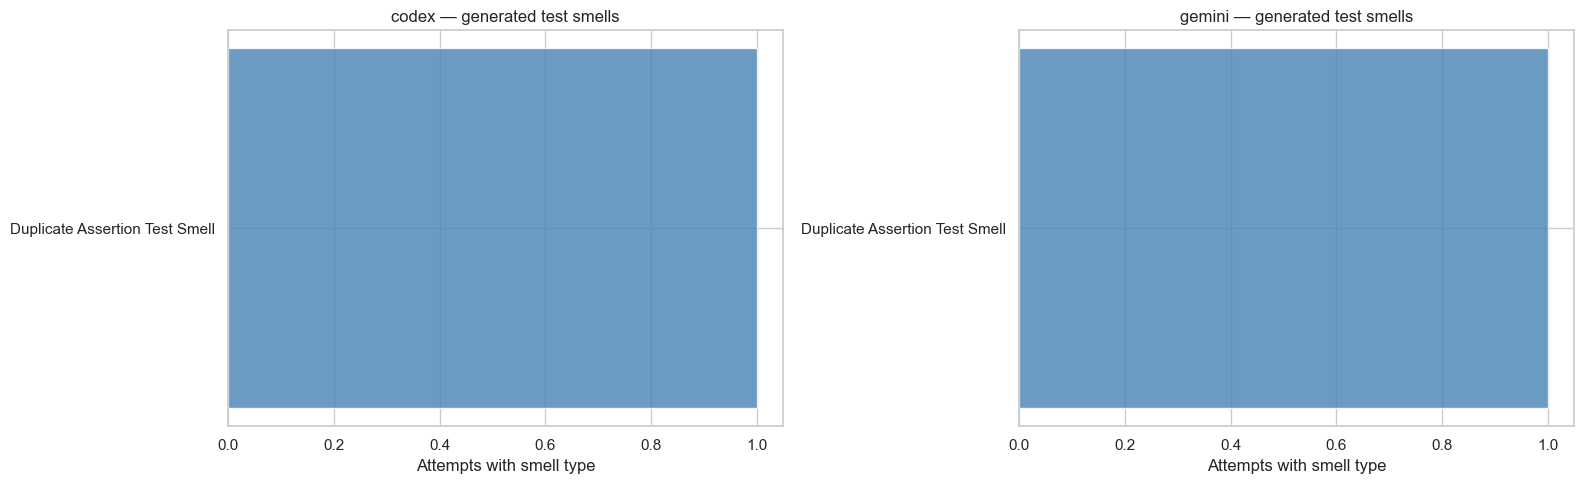

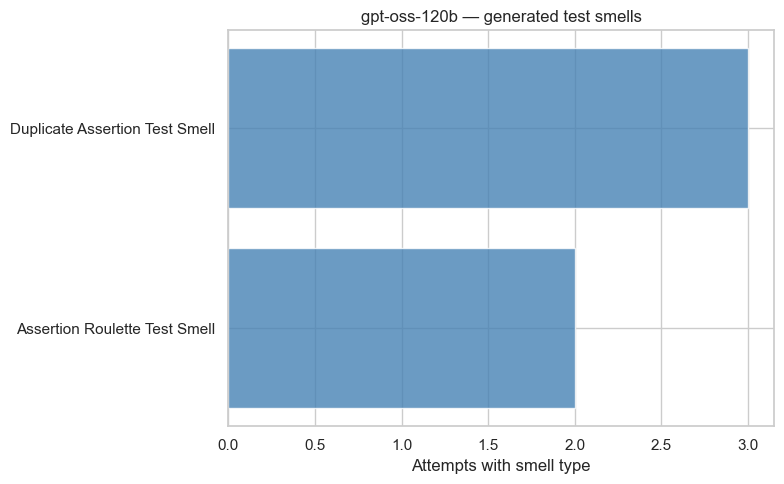

In [11]:
from analysis.plots import smell_type_breakdown

# Smell count by model/tool
for label, df, group_col in [('LLM by model', llm, 'model'), ('Agentic by tool', agentic, 'tool_id')]:
    if group_col not in df.columns or 'generated_test_smell_count' not in df.columns:
        continue
    print(f'{label} — generated test smell counts:')
    display(df.groupby(group_col)['generated_test_smell_count'].agg(['sum', 'mean', 'median']).round(2))
    print()

# Type breakdown per tool (agentic)
if 'tool_id' in agentic.columns and 'generated_test_smell_types' in agentic.columns:
    tools = sorted(agentic['tool_id'].dropna().unique())
    if tools:
        fig, axes = plt.subplots(1, len(tools), figsize=(8 * len(tools), 5), squeeze=False)
        for ax, tool in zip(axes[0], tools):
            smell_type_breakdown(agentic[agentic['tool_id'] == tool], 'generated_test_smell_types', ax=ax)
            ax.set_title(f'{tool} — generated test smells')
        plt.tight_layout()
        plt.show()

# Type breakdown per model (LLM)
if 'model' in llm.columns and 'generated_test_smell_types' in llm.columns:
    models = sorted(llm['model'].dropna().unique())
    if models:
        fig, axes = plt.subplots(1, len(models), figsize=(8 * len(models), 5), squeeze=False)
        for ax, model in zip(axes[0], models):
            smell_type_breakdown(llm[llm['model'] == model], 'generated_test_smell_types', ax=ax)
            ax.set_title(f'{model} — generated test smells')
        plt.tight_layout()
        plt.show()

## 10. Timing and Token Efficiency by Model/Tool

Median generation and validation duration, plus token consumption, broken down per model/tool. Provides the input needed for total-cost calculations and helps identify models that are slow not because of validation but because of generation.


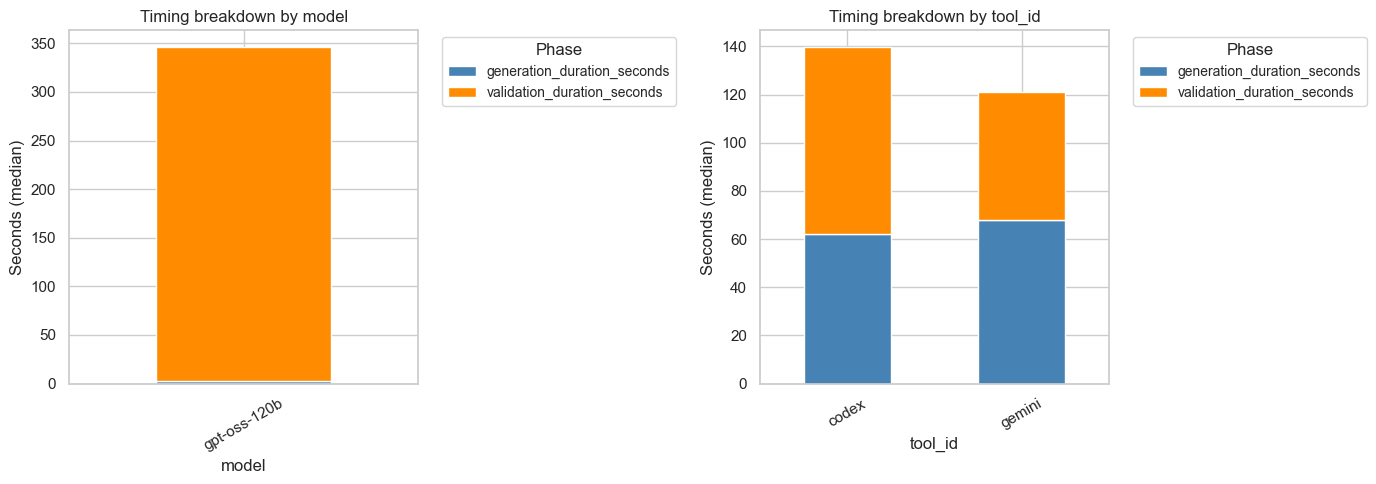


LLM timing/token summary (median):


,total_tokens,generation_duration_seconds,validation_duration_seconds
model,,,
gpt-oss-120b,2640.0,2.1,343.8



Agentic timing/token summary (median):


,total_tokens,generation_duration_seconds,validation_duration_seconds
tool_id,,,
codex,259516.0,62.1,77.5
gemini,178629.0,68.0,53.0


In [12]:
from analysis.plots import timing_stacked_bar

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if 'model' in llm.columns:
    timing_stacked_bar(llm, group_col='model', ax=axes[0])
if 'tool_id' in agentic.columns:
    timing_stacked_bar(agentic, group_col='tool_id', ax=axes[1])
plt.tight_layout()
plt.show()

token_cols = [c for c in ['total_tokens', 'generation_duration_seconds', 'validation_duration_seconds']
              if c in attempts.columns]
if token_cols:
    for label, df, group_col in [('LLM', llm, 'model'), ('Agentic', agentic, 'tool_id')]:
        if group_col in df.columns:
            cols_present = [c for c in token_cols if c in df.columns]
            print(f'\n{label} timing/token summary (median):')
            display(df.groupby(group_col)[cols_present].median().round(1))

## 11. Repair Efficacy (LLM Lane, RQ2)

Does the repair chain convert first-attempt failures into successes? Per LLM candidate chain:
first-attempt success, whether any repair attempt succeeded, at which attempt success first
occurred, and the conversion rate (rescued / needed-repair). Cumulative chain tokens give the
cost. The agentic lane is single-shot and excluded.

In [13]:
import numpy as np

llm_chain = attempts[attempts['lane'] == 'llm'].copy()
if {'attempt_number', 'candidate_key', 'validated_success'} <= set(llm_chain.columns):
    llm_chain['attempt_number'] = pd.to_numeric(llm_chain['attempt_number'], errors='coerce')
    rows = []
    for ck, g in llm_chain.groupby('candidate_key'):
        g = g.sort_values('attempt_number')
        succ = g['validated_success'].astype(bool).values
        ever = bool(succ.any())
        first = bool(succ[0]) if len(succ) else False
        rows.append({
            'candidate': str(ck).split('|')[-1],
            'model': g['model'].iloc[0] if 'model' in g.columns else '',
            'attempts': len(g),
            'first_try_success': first,
            'ever_success': ever,
            'success_at_attempt': int(np.argmax(succ) + 1) if ever else None,
            'rescued_by_repair': ever and not first,
            'chain_tokens': (pd.to_numeric(g['cumulative_tokens'], errors='coerce').max()
                             if 'cumulative_tokens' in g.columns else np.nan),
        })
    chain = pd.DataFrame(rows)
    display(chain)

    needed = int((~chain['first_try_success']).sum())
    rescued = int(chain['rescued_by_repair'].sum())
    if needed:
        print(f'Failed first attempt (needed repair): {needed}; rescued by repair: {rescued}/{needed} ({rescued / needed:.0%})')
    else:
        print('No candidate needed repair (all first attempts resolved).')

    multi = chain[chain['attempts'] > 1]
    if len(multi):
        print(f'Multi-attempt chains: {len(multi)}; median attempts={multi["attempts"].median():.0f}; median chain tokens={multi["chain_tokens"].median():.0f}')

    if 'model' in chain.columns and chain['model'].nunique() > 0:
        pm = chain.groupby('model').apply(lambda d: pd.Series({
            'chains': len(d),
            'needed_repair': int((~d['first_try_success']).sum()),
            'rescued': int(d['rescued_by_repair'].sum()),
            'final_success_rate': d['ever_success'].mean(),
        }))
        print('\nPer-model repair summary:')
        display(pm.round(3))
else:
    print('Repair-chain columns (attempt_number, candidate_key) not available.')

,candidate,model,attempts,first_try_success,ever_success,success_at_attempt,rescued_by_repair,chain_tokens
0,2,gpt-oss-120b,1,True,True,1,False,2640
1,478,gpt-oss-120b,2,False,True,2,True,8180


Failed first attempt (needed repair): 1; rescued by repair: 1/1 (100%)
Multi-attempt chains: 1; median attempts=2; median chain tokens=8180

Per-model repair summary:


,chains,needed_repair,rescued,final_success_rate
model,,,,
gpt-oss-120b,2.0,1.0,1.0,1.0
